# 1. Identificação do Grupo

**Disciplina:** Processamento Digital de Imagens

| Nome | RA |
|---|---|
| Igor Ladeia de Freitas | 11201922180 |
| Gustavo Fernandes do Nascimento | 11202021700 |
| Ryan Lucas da Silva | 11202522362 |
| Eduardo Yukio Makita | 11202020221 |

# 2. Introdução e Motivação

Este trabalho apresenta um sistema de rastreamento de robôs para futebol de robôs (RoboCup/VSS), utilizando técnicas de processamento digital de imagens.

O objetivo é detectar e rastrear robôs e a bola em tempo real a partir de vídeo capturado por uma câmera posicionada acima do campo. Cada robô possui uma etiqueta colorida composta por uma cor de time (azul ou amarelo) e duas cores de identificação, permitindo distinguir até 10 robôs por time.

A motivação principal é aplicar na prática os conceitos estudados na disciplina — segmentação por cor no espaço HSV, operações morfológicas, calibração por homografia e correção de distorção — em um cenário real e desafiador.

# 3. Fundamentação Teórica

## 3.1 Espaço de Cor HSV

O espaço HSV (Hue, Saturation, Value) separa a informação de cor (matiz) da luminosidade, facilitando a segmentação por cor sob variações de iluminação.

A conversão de RGB para HSV é definida por:

$$V = \max(R, G, B)$$

$$S = \begin{cases} \frac{V - \min(R,G,B)}{V} & \text{se } V \neq 0 \\ 0 & \text{caso contrário} \end{cases}$$

$$H = \begin{cases} 60 \cdot \frac{G - B}{V - \min(R,G,B)} & \text{se } V = R \\ 60 \cdot \left(2 + \frac{B - R}{V - \min(R,G,B)}\right) & \text{se } V = G \\ 60 \cdot \left(4 + \frac{R - G}{V - \min(R,G,B)}\right) & \text{se } V = B \end{cases}$$

## 3.2 Filtro Gaussiano

O filtro Gaussiano suaviza a imagem para reduzir ruído, utilizando um kernel definido por:

$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

A convolução com este kernel atenua componentes de alta frequência (ruído) preservando bordas suaves.

## 3.3 CLAHE (Contrast Limited Adaptive Histogram Equalization)

O CLAHE melhora o contraste local dividindo a imagem em blocos e aplicando equalização de histograma com limite de recorte (*clip limit*). Para cada bloco, o histograma é redistribuído:

$$\text{Se } h(i) > T_{\text{clip}}, \text{ o excesso } \sum_{i} \max(0, h(i) - T_{\text{clip}}) \text{ é redistribuído uniformemente.}$$

Aplicamos CLAHE no canal V do espaço HSV para normalizar a luminosidade sem alterar as cores.

## 3.4 Operações Morfológicas

Operações morfológicas processam imagens binárias usando um elemento estruturante $B$:

- **Erosão:** $A \ominus B = \{z \mid B_z \subseteq A\}$
- **Dilatação:** $A \oplus B = \{z \mid B_z \cap A \neq \emptyset\}$
- **Abertura (Opening):** $A \circ B = (A \ominus B) \oplus B$ — remove pequenos ruídos.
- **Fechamento (Closing):** $A \bullet B = (A \oplus B) \ominus B$ — preenche pequenos buracos.

Utilizamos abertura com kernel elíptico para limpar as máscaras de segmentação.

## 3.5 Segmentação por Cor

A segmentação é feita por limiarização no espaço HSV. Para cada cor $c$, definimos faixas $(H_{\min}, S_{\min}, V_{\min})$ e $(H_{\max}, S_{\max}, V_{\max})$:

$$M_c(x,y) = \begin{cases} 255 & \text{se } H_{\min} \leq H(x,y) \leq H_{\max} \land S_{\min} \leq S(x,y) \leq S_{\max} \land V_{\min} \leq V(x,y) \leq V_{\max} \\ 0 & \text{caso contrário} \end{cases}$$

Para cores como vermelho, cujo matiz cruza o limite 0/180, utilizamos a união de duas faixas.

## 3.6 Homografia

A homografia mapeia coordenadas de pixel para coordenadas do campo usando uma transformação projetiva $3 \times 3$:

$$\begin{bmatrix} x' \\ y' \\ w' \end{bmatrix} = H \begin{bmatrix} u \\ v \\ 1 \end{bmatrix}, \quad \text{com } (X, Y) = \left(\frac{x'}{w'}, \frac{y'}{w'}\right)$$

A matriz $H$ é estimada a partir de 4 correspondências ponto-a-ponto (cantos do campo) usando o algoritmo DLT (*Direct Linear Transform*).

## 3.7 Correção de Distorção

Lentes reais introduzem distorção radial modelada por:

$$x_{\text{distorcido}} = x(1 + k_1 r^2 + k_2 r^4), \quad r^2 = x^2 + y^2$$

Os coeficientes $k_1, k_2$ são estimados via `cv2.calibrateCamera` a partir de 8 pontos coplanares. Com apenas 4 pontos de calibração, não há dados suficientes para estimar a distorção.

# 4. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from robofoot_tracker import (
    Tracker, draw_detections, FieldDimensions,
    ColorConfig, TEAM_COLORS, ID_COLORS,
    preprocess_frame, calibrate_from_points, detect_robots, detect_ball,
)

CALIBRATION_POINTS = [(100, 80), (540, 80), (540, 400), (100, 400)]
VIDEO_PATH = 'video.mp4'

# 5. Demonstração do Pipeline

Nesta seção demonstramos cada etapa do pipeline de detecção em um único frame.

In [2]:
# Carregar um frame válido (pular frames escuros iniciais)
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 4)
ret, frame = cap.read()
cap.release()
assert ret, 'Falha ao ler frame'

## 5.1 Pré-processamento: Antes e Depois + Histogramas do Canal V

Aplicamos CLAHE no canal V (luminosidade) do espaço HSV, seguido de suavização Gaussiana. Isso normaliza a iluminação sem alterar as cores.

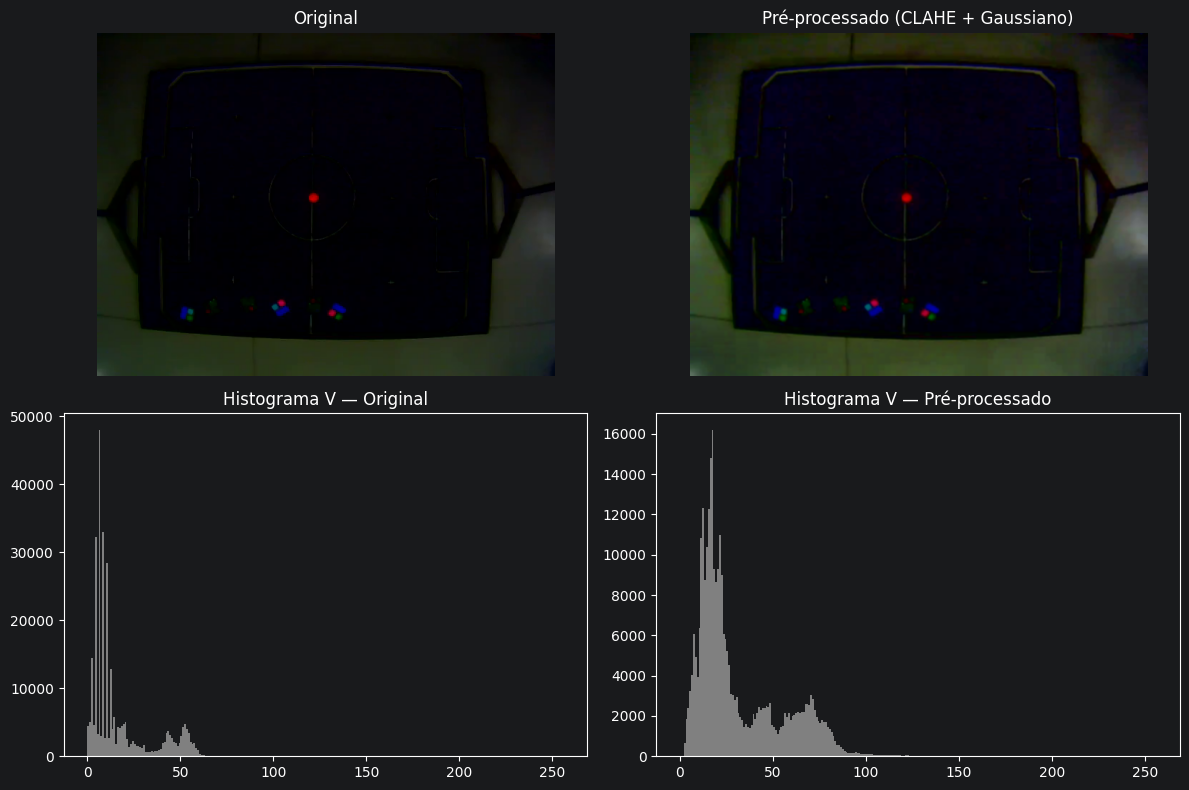

In [3]:
preprocessed = preprocess_frame(frame)

v_before = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)[:, :, 2]
v_after = cv2.cvtColor(preprocessed, cv2.COLOR_BGR2HSV)[:, :, 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
axes[0, 1].imshow(cv2.cvtColor(preprocessed, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Pré-processado (CLAHE + Gaussiano)')
axes[0, 1].axis('off')
axes[1, 0].hist(v_before.ravel(), bins=256, range=(0, 256), color='gray')
axes[1, 0].set_title('Histograma V — Original')
axes[1, 1].hist(v_after.ravel(), bins=256, range=(0, 256), color='gray')
axes[1, 1].set_title('Histograma V — Pré-processado')
plt.tight_layout()
plt.show()

## 5.2 Máscaras de Cor e Operações Morfológicas

Convertemos o frame para HSV e aplicamos `cv2.inRange` com as faixas de cada cor. Em seguida, demonstramos o efeito da abertura morfológica (erosão + dilatação) para remover ruído.

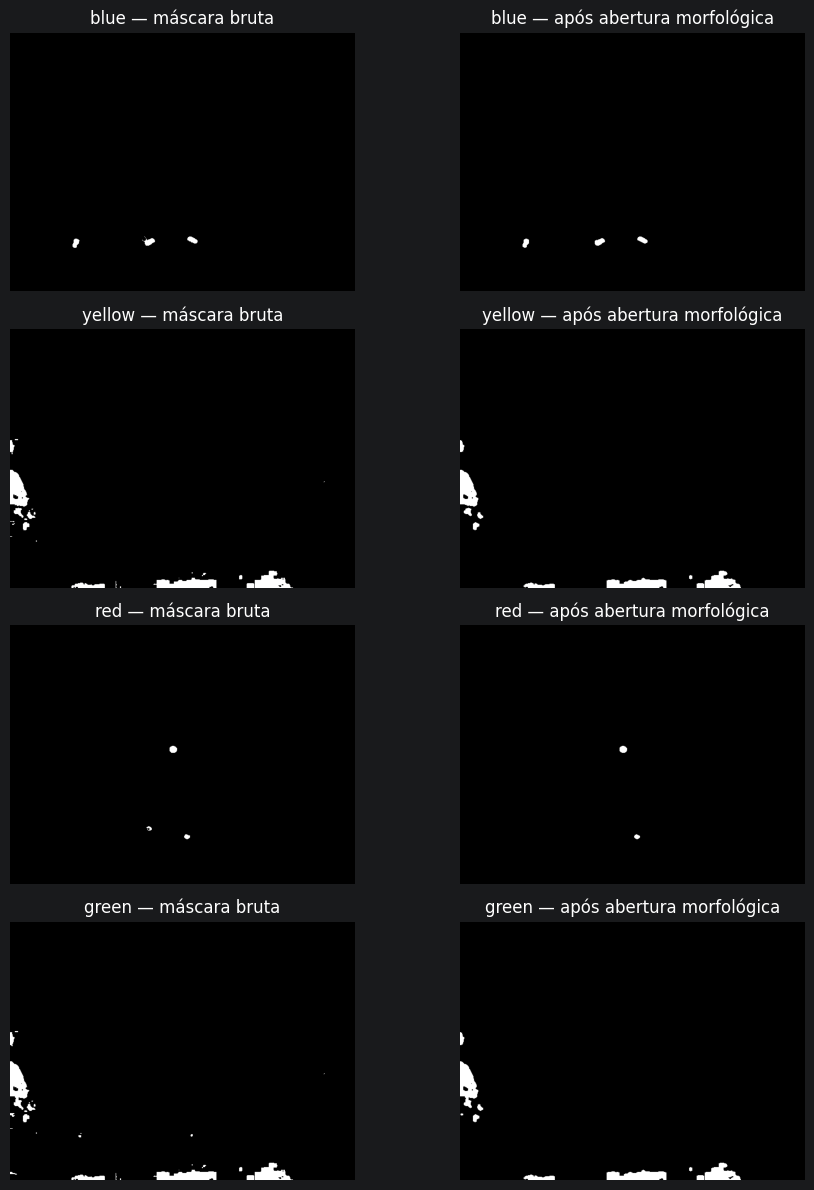

In [4]:
hsv = cv2.cvtColor(preprocessed, cv2.COLOR_BGR2HSV)
cc = ColorConfig()
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

colors_to_show = ['blue', 'yellow', 'red', 'green']
fig, axes = plt.subplots(len(colors_to_show), 2, figsize=(10, 3 * len(colors_to_show)))

for i, color in enumerate(colors_to_show):
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lo, hi in cc.get_ranges(color):
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, lo, hi))
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    axes[i, 0].imshow(mask, cmap='gray')
    axes[i, 0].set_title(f'{color} — máscara bruta')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(opened, cmap='gray')
    axes[i, 1].set_title(f'{color} — após abertura morfológica')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 5.3 Calibração com 4 Pontos

Utilizamos 4 pontos correspondentes aos cantos do campo (TL, TR, BR, BL) para calcular a matriz de homografia que mapeia coordenadas de pixel para coordenadas do campo em centímetros.

In [5]:
calibration = calibrate_from_points(CALIBRATION_POINTS, FieldDimensions())
print('Matriz de homografia:')
print(calibration.homography_matrix)
print(f'\nPontos de origem (pixels): {calibration.src_points.tolist()}')
print(f'Pontos de destino (campo cm): {calibration.dst_points.tolist()}')

Matriz de homografia:
[[  0.34090909   0.         -34.09090909]
 [  0.           0.40625    -32.5       ]
 [  0.           0.           1.        ]]

Pontos de origem (pixels): [[100.0, 80.0], [540.0, 80.0], [540.0, 400.0], [100.0, 400.0]]
Pontos de destino (campo cm): [[0.0, 0.0], [150.0, 0.0], [150.0, 130.0], [0.0, 130.0]]


## 5.4 Correção de Distorção

O método `tracker.undistort_frame(frame)` aplica correção de distorção radial quando os coeficientes estão disponíveis.

Com a calibração de 4 pontos utilizada neste notebook, **não há dados de distorção** — a função retorna o frame inalterado (passthrough). Para habilitar a correção de distorção, é necessário utilizar a calibração interativa de 8 pontos (`calibrate_interactive`), que estima os coeficientes $k_1$ e $k_2$ via `cv2.calibrateCamera`.

```python
# Exemplo de uso (requer calibração interativa com 8 pontos):
tracker = Tracker(video_path='video.mp4')  # sem calibration_points → abre janela interativa
# Após calibração interativa com 8 pontos:
# tracker.calibration.camera_matrix e tracker.calibration.dist_coeffs estarão preenchidos
undistorted = tracker.undistort_frame(frame)  # aplica cv2.undistort
```

In [6]:
tracker_demo = Tracker(video_path=VIDEO_PATH, calibration_points=CALIBRATION_POINTS)
# Forçar calibração para popular o atributo
cap = cv2.VideoCapture(VIDEO_PATH)
tracker_demo._calibrate_first_frame(cap)
cap.release()

undistorted = tracker_demo.undistort_frame(frame)
print(f'camera_matrix: {tracker_demo.calibration.camera_matrix}')
print(f'dist_coeffs: {tracker_demo.calibration.dist_coeffs}')
print(f'Frame inalterado (passthrough): {np.array_equal(frame, undistorted)}')

camera_matrix: None
dist_coeffs: None
Frame inalterado (passthrough): True


## 5.5 Detecção e Anotação

Executamos `detect_robots` e `detect_ball` no frame pré-processado e visualizamos o resultado com `draw_detections`.

Robôs detectados: 0
Bola: não detectada


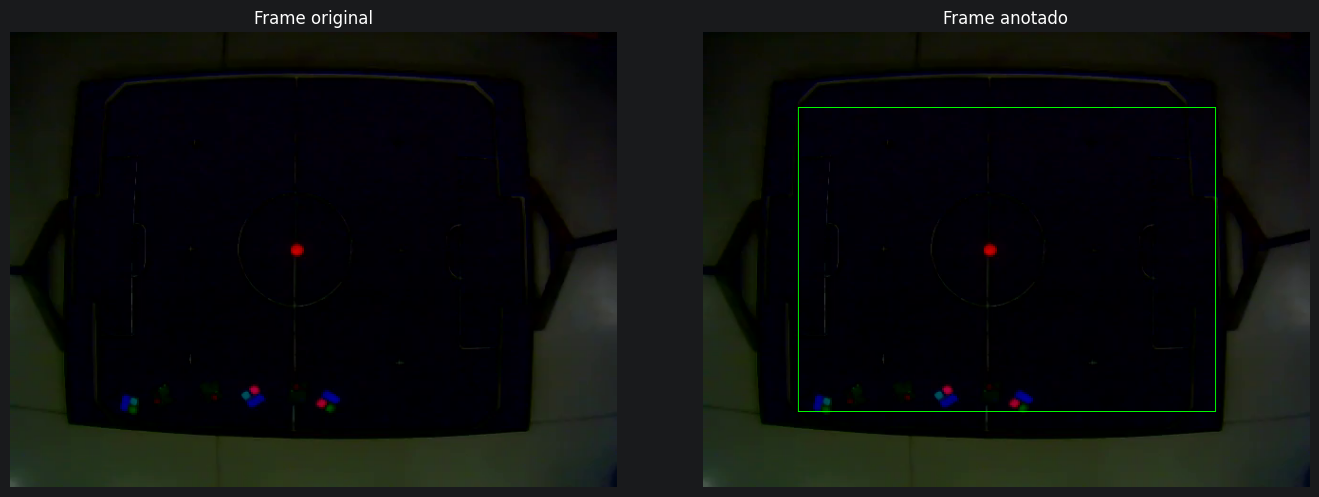

In [7]:
robots = detect_robots(preprocessed, calibration, ColorConfig(), teams='both')
ball = detect_ball(preprocessed, calibration, ColorConfig())

print(f'Robôs detectados: {len(robots)}')
for r in robots:
    print(f'  {r.team} #{r.robot_id} — pos=({r.position[0]:.1f}, {r.position[1]:.1f}) cm, ângulo={r.angle_deg:.1f}°')
print(f'Bola: {ball.position if ball else "não detectada"}')

from robofoot_tracker import FrameResult
annotated = draw_detections(frame, robots, calibration, ball=ball)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Frame original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title('Frame anotado')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# 6. Processamento de Vídeo

Iteramos 30 frames do vídeo usando o `Tracker`, anotamos cada frame com `draw_detections` e salvamos o resultado em `output_annotated.mp4`.

Vídeo salvo: output_annotated.mp4


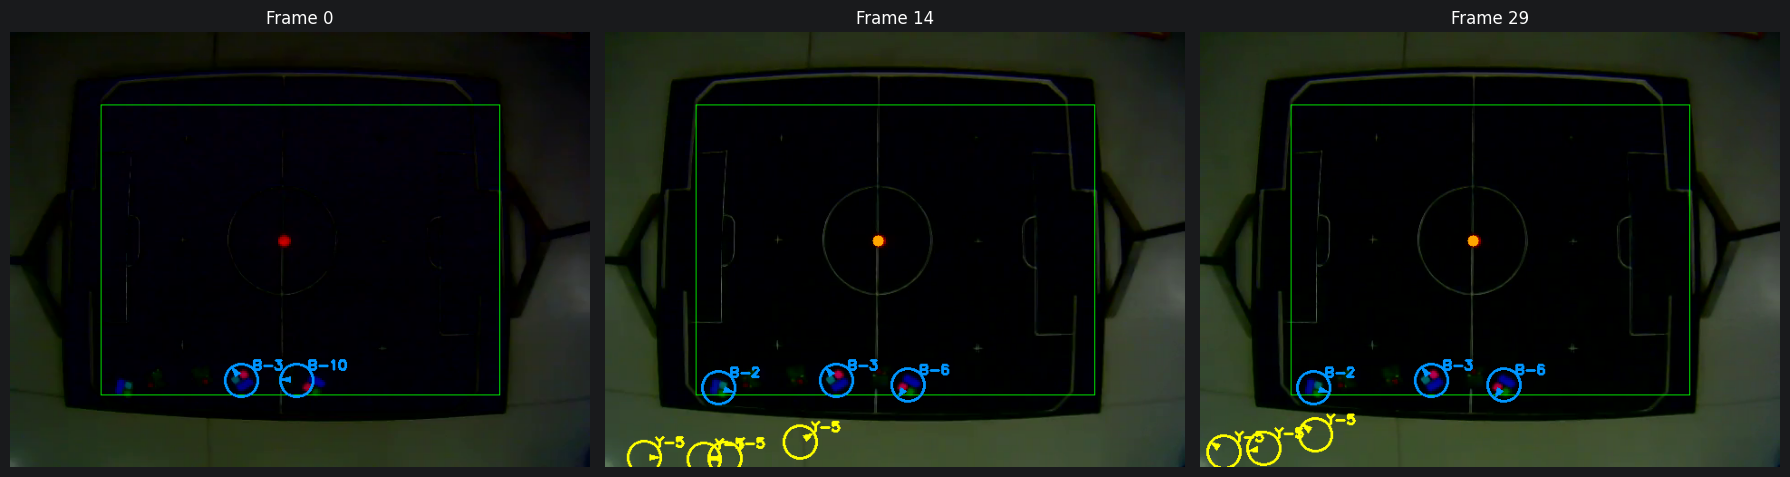

In [8]:
tracker = Tracker(video_path=VIDEO_PATH, calibration_points=CALIBRATION_POINTS, teams='both')
writer = None
sample_frames = []

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
cap.release()

for i, result in enumerate(tracker):
    if i >= 30:
        break
    # Ler o frame correspondente para anotação
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, result.frame_index)
    ret, f = cap.read()
    cap.release()
    if not ret:
        continue
    annotated = draw_detections(f, result.detections, tracker.calibration, ball=result.ball)
    if writer is None:
        h, w = annotated.shape[:2]
        writer = cv2.VideoWriter('output_annotated.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    writer.write(annotated)
    if i in (0, 14, 29):
        sample_frames.append((i, annotated.copy()))

if writer:
    writer.release()
    print('Vídeo salvo: output_annotated.mp4')

if sample_frames:
    fig, axes = plt.subplots(1, len(sample_frames), figsize=(6 * len(sample_frames), 5))
    if len(sample_frames) == 1:
        axes = [axes]
    for ax, (idx, sf) in zip(axes, sample_frames):
        ax.imshow(cv2.cvtColor(sf, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Frame {idx}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 7. Modo Webcam

O código abaixo demonstra como utilizar o `Tracker` em modo webcam para detecção em tempo real. **Este código não é executado no notebook** pois requer acesso a uma câmera e interface gráfica.

```python
```

O método `run_live()` abre uma janela OpenCV que exibe os frames anotados em tempo real. A calibração é feita automaticamente no primeiro frame. Pressione ESC ou 'q' para encerrar.

In [9]:
# Modo webcam — executar somente com a câmera posicionada corretamente
# tracker = Tracker(
#     camera=2,
#     # calibration_points=CALIBRATION_POINTS,
#     teams='both',
#     color_calibration=True,
# )
# tracker.run_live()  # Abre janela OpenCV, ESC ou 'q' para sair

QFontDatabase: Cannot find font directory /home/yukio/Documents/UFABC/trabalho/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/yukio/Documents/UFABC/trabalho/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/yukio/Documents/UFABC/trabalho/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/yukio/Documents/UFABC/trabalho/.venv/lib64/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch

[[56.280941009521484, 46.442138671875, 351.29], [102.23806762695312, 84.15091705322266, 118.71], [18.164369583129883, 38.23384094238281, 101.5]]
[[56.28931427001953, 46.458656311035156, 350.94], [102.23328399658203, 84.1315689086914, 118.98], [18.164369583129883, 38.23384094238281, 101.5]]
[[56.2762451171875, 46.480464935302734, 349.42], [102.24102020263672, 84.12960052490234, 118.27], [18.161285400390625, 38.25285339355469, 101.2]]
[[56.30162811279297, 46.461631774902344, 350.28], [102.21908569335938, 84.1285400390625, 118.53], [18.165559768676758, 38.254425048828125, 101.08]]
[[56.2334098815918, 46.47175598144531, 349.53], [102.23825073242188, 84.13347625732422, 118.71], [18.167428970336914, 38.239776611328125, 101.43]]
[[56.24687194824219, 46.47298812866211, 350.21], [102.24353790283203, 84.14575958251953, 118.72], [18.168045043945312, 38.24662399291992, 101.45]]
[[56.24422836303711, 46.493263244628906, 349.68], [102.22654724121094, 84.1433334350586, 118.52], [18.16498374938965, 38.

# 8. Métricas

Após o processamento do vídeo na Seção 6, o `Tracker` acumula métricas de desempenho acessíveis via `tracker.metrics`.

In [10]:
print(tracker.metrics.summary())

FPS: 11.85
Total frames: 1483
Skipped frames: 0
Detection rate: 100.00%
Ball detection rate: 100.00%
Team detection counts: {'blue': 1483, 'yellow': 2966}
Total processing time: 125.15s


# 9. Conclusão

Neste trabalho implementamos e demonstramos um pipeline completo de rastreamento de robôs para futebol de robôs, utilizando exclusivamente técnicas de processamento digital de imagens.

O sistema é capaz de:
- **Pré-processar** frames com CLAHE e filtro Gaussiano para normalizar iluminação;
- **Segmentar** robôs e bola por cor no espaço HSV, com operações morfológicas para limpeza;
- **Calibrar** a câmera via homografia (4 pontos) ou com correção de distorção (8 pontos interativos);
- **Detectar** a posição e orientação de cada robô, bem como a posição da bola;
- **Anotar** e exportar vídeos processados;
- Operar em **tempo real** via webcam.

As principais limitações observadas incluem sensibilidade às condições de iluminação e à qualidade da calibração manual dos pontos. Como trabalhos futuros, sugerimos a exploração de calibração automática por detecção de marcadores e o uso de filtros de Kalman para suavizar as trajetórias estimadas.